## Tools Setup

In [12]:
import pathlib, os, sys, operator, re, datetime
from functools import reduce
import numpy as np
import tensorflow as tf
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import Model
import tensorflow_datasets as tfds
from tiny_imagenet import TinyImagenetDataset

# Enable or disable GPU
# To fully disable it, we need to hide all GPU devices from Tensorflow
# Make sure GPU is disabled for this inference part of the lab
ENABLE_GPU = False
# tf.debugging.set_log_device_placement(True)

if not ENABLE_GPU:
    tf.config.set_visible_devices([], 'GPU')

# Print Python and TF version, and where we are running
print(f'Running on Python Version: {sys.version}')
print(f'Using Tensorflow Version: {tf. __version__}')
if not tf.config.experimental.list_physical_devices("GPU"):
    print('Running on CPU')
else:
    print(f'Using GPU at: {tf.test.gpu_device_name()} (of {len(tf.config.experimental.list_physical_devices("GPU"))} available)')

Running on Python Version: 3.9.25 (main, Aug  6 2026, 00:00:00) 
[GCC 11.5.0 20240719 (Red Hat 11.5.0-14)]
Using Tensorflow Version: 2.16.2
Running on CPU


## Dataset Inspection

In [13]:
# This cell imports our dataset.

# Original Source: https://github.com/ksachdeva/tiny-imagenet-tfds
# Class Version Source: https://github.com/duweisu/tiny-imagenet-tfds
# Setup our dataset
# ---------------------------------------------------------

tiny_imagenet_builder = TinyImagenetDataset()

# this call (download_and_prepare) will trigger the download of the dataset
# and preparation (conversion to tfrecords)
#
# This will be done only once and on next usage tfds will
# use the cached version on your host.
tiny_imagenet_builder.download_and_prepare(download_dir="~/tensorflow-datasets/downloads")

# class_names = tiny_imagenet_builder.info.features['label'].names
ds = tiny_imagenet_builder.as_dataset()
ds_train, ds_val = ds["train"], ds["validation"]
assert(isinstance(ds_train, tf.data.Dataset))
assert(isinstance(ds_val, tf.data.Dataset))

# Training Dataset
ds_train = ds_train.shuffle(1024).prefetch(tf.data.AUTOTUNE)

# Validation Dataset
ds_val = ds_val.shuffle(1024).prefetch(tf.data.AUTOTUNE)

# Dataset metadata
ds_info = tiny_imagenet_builder.info

In [14]:
# We need to read the "human readable" labels so we can translate with the numeric values
# Read the labels file (words.txt)
with open(os.path.abspath('wnids.txt'), 'r') as f:
    wnids = [x.strip() for x in f]

# Map wnids to integer labels
wnid_to_label = {wnid: i for i, wnid in enumerate(wnids)}
label_to_wnid = {v: k for k, v in wnid_to_label.items()}

# Use words.txt to get names for each class
with open(os.path.abspath('words.txt'), 'r') as f:
    wnid_to_words = dict(line.split('\t') for line in f)
    for wnid, words in wnid_to_words.items():
        wnid_to_words[wnid] = [w.strip() for w in words.split(',')]
        
class_names = [str(wnid_to_words[wnid]) for wnid in wnids]

In [15]:
# Helper function to get the label name
def img_class(img_data, idx=None):
    image, label, id, label_name = img_data["image"], img_data["label"], img_data["id"], img_data["metadata"]['label_name']
    # Handle batches of images correctly
    if idx != None:
        image, label, id, label_name = img_data["image"][idx], img_data["label"][idx], img_data["id"][idx], img_data["metadata"]['label_name'][idx]
    
    return f"{label_name} (class index: {label} - id: {id})"


# Helper function to show basic info about an image
def img_info(img, idx=None, display=True, title_apend=""):
    image = img['image']

    # Print the class
    class_str = img_class(img, idx)
    print(f"Label: {class_str}")
    
    # Display the image
    if display:
        plt.figure()
        plt.title(title_apend + class_str)
        # Handle batches correctly
        if image.shape.ndims > 3:
            plt.imshow(image.numpy().reshape(64, 64, 3))
        else:
            plt.imshow(image.numpy())

--- Train & Validation dataset info ---
Train: <_PrefetchDataset element_spec={'id': TensorSpec(shape=(), dtype=tf.string, name=None), 'image': TensorSpec(shape=(64, 64, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'metadata': {'label_name': TensorSpec(shape=(), dtype=tf.string, name=None)}}>
Validation: <_PrefetchDataset element_spec={'id': TensorSpec(shape=(), dtype=tf.string, name=None), 'image': TensorSpec(shape=(64, 64, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'metadata': {'label_name': TensorSpec(shape=(), dtype=tf.string, name=None)}}>

--- Show an example image ---
Label: b'convertible' (class index: 157 - id: b'n03100240')

 Show some other examples


2026-08-31 18:32:03.759226: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-08-31 18:32:03.768796: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-08-31 18:32:03.929854: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.

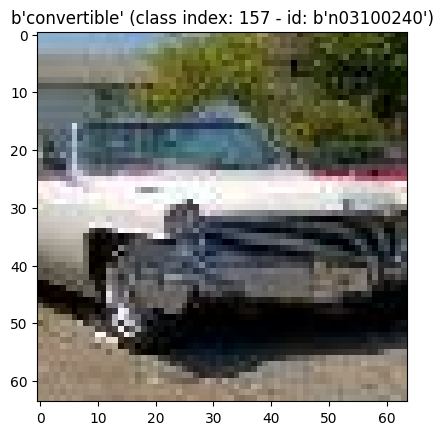

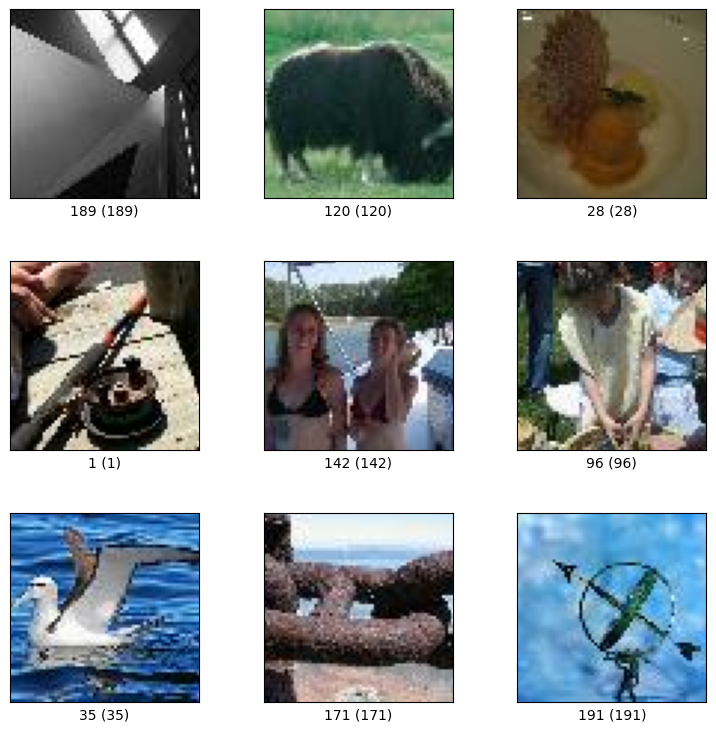

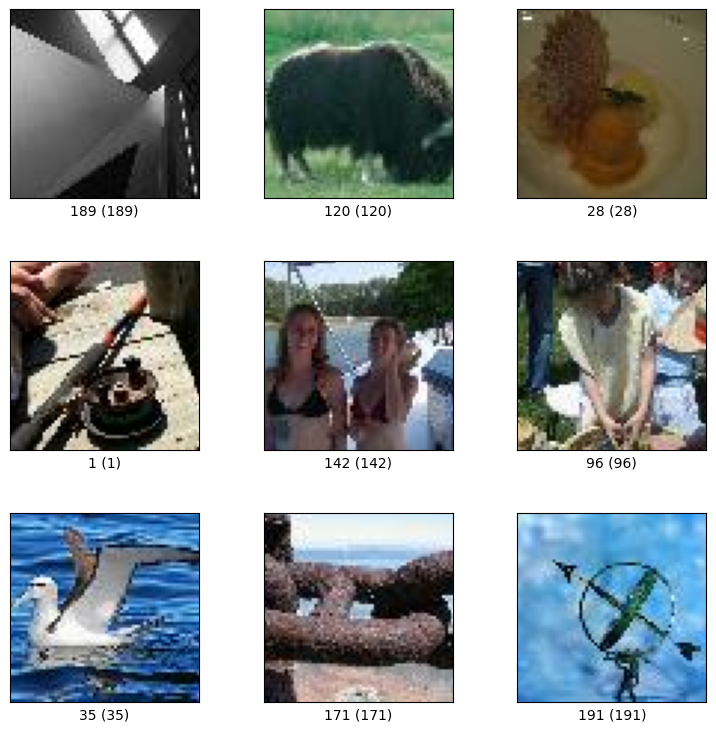

In [16]:
# Print the dataset types and info
print("--- Train & Validation dataset info ---")
print(f"Train: {ds_train}")
print(f"Validation: {ds_val}")
# print(f"Dataset Info: {ds_info}") # Uncomment to print Dataset info

print("\n--- Show an example image ---")
for example in ds_val.take(1):
    img_info(example)

print("\n Show some other examples")
tfds.show_examples(ds_val, ds_info, rows=3, cols=3)


--- Image 0 ---
Label: b'snail' (class index: 33 - id: b'n01944390')
Data type: <dtype: 'uint8'>
Dimensions: (64, 64, 3)
Memory required: 12288 bytes

--- Image 1 ---
Label: b'cannon' (class index: 80 - id: b'n02950826')
Data type: <dtype: 'uint8'>
Dimensions: (64, 64, 3)
Memory required: 12288 bytes

--- Image 2 ---
Label: b'vestment' (class index: 104 - id: b'n04532106')
Data type: <dtype: 'uint8'>
Dimensions: (64, 64, 3)
Memory required: 12288 bytes


2026-08-31 18:32:04.811489: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-08-31 18:32:04.821094: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


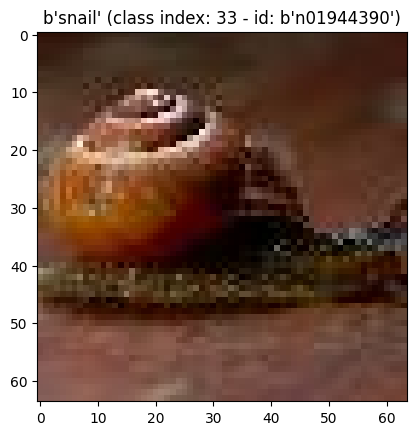

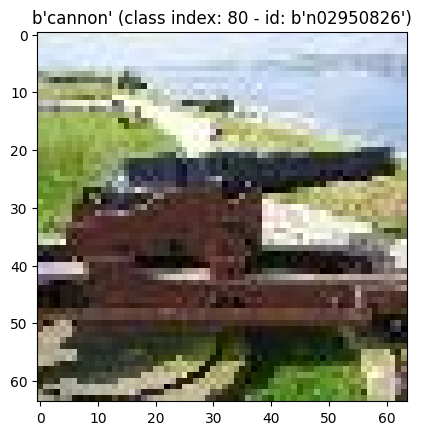

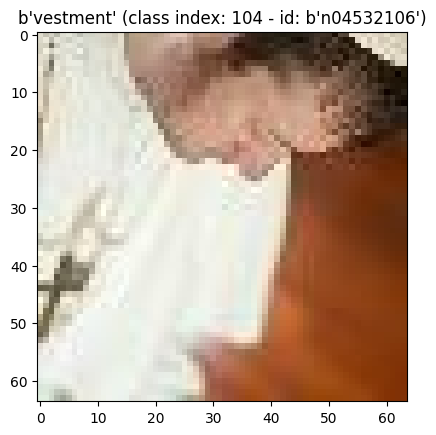

In [17]:
# TODO: Print and visualize three inputs from the validation set
#     : Print the stroage data type
#     : Print and note the dimensions of each image
#     : Print the memory required to store each image

# Sample Images
sample_imgs = []
for index, img_data in enumerate(ds_val.take(3)):
    sample_imgs.append(img_data)
    image, label, id, label_name = img_data["image"], img_data["label"], img_data["id"], img_data["metadata"]['label_name']

    print(f'\n--- Image {index} ---')
    # TODO: Your Code Here
    img_info(img_data)

    print(f"Data type: {image.dtype}")
    print(f"Dimensions: {image.shape}")
    print(f"Memory required: {image.numpy().nbytes} bytes")
    # See example usage: https://github.com/duweisu/tiny-imagenet-tfds

In [18]:
# TODO: Export each of the three inputs to a binary file which will be used to load the images into C++ later
# NOTE: First flatten the array (ex: 4D --> 1D). So 64*64*3 = 12288 element 1D array

# Make a directory for our image data
img_dir = os.path.abspath('img_data')
pathlib.Path(img_dir).mkdir(exist_ok=True)

# Create a metadata file
metadata_file = open(os.path.join(img_dir, f'metadata.txt'), 'w')
metadata_file.write(f'Number\t\tDims\t\tClass Data\n')

# Export each image
for index, img_data in enumerate(sample_imgs):    
    img_file = open(os.path.join(img_dir, f'image_{index}.bin'), 'wb')
    
    # TODO: Your Code Here
    image = img_data["image"].numpy().flatten()#by numpy() -> encoding image tensor to numpy array and by flatten() change numpy array to one dimensions 64*64*3 ==> 12288
    img_file.write(image.tobytes())#convert unit8 12288 to raw byte 12288(real bytes)

    metadata_file.write(
        f"{index}\t\t{image.shape}\t\t{img_class(img_data)}\n"#writing image dimensions and image class and store into metadata.txt
    )

    img_file.close()#after writing all things -> finish to change unit8 to raw byte and store into binary info files.
metadata_file.close()#finish to write

## Model Loading and Inference

In [19]:
# TODO: Load the model
# Now we will load the H5 model! Please make sure the h5 model file is present in the below directory.
# You can download this from the Canvas Page and place it in the same directory as this notebook.

# model_path = os.path.abspath(""/home/<NETID>/path/to/your/lab1/CNN_TinyImageNet.h5)" # Uncomment this to use a non-relative path
model_path = os.path.abspath("CNN_TinyImageNet.h5")

# TODO: Your Code Here
model = tf.keras.models.load_model(model_path)
model.summary()

/home/zachdixo/cpre-487/lab01/lab1_venv/lib64/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/zachdixo/cpre-487/lab01/lab1_venv/lib64/python3.9/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 60, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770,218 (2.94 MB)

 Trainable params: 770,216 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

2026-08-31 18:32:05.661373: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


Label: [b'tarantula'] (class index: [43] - id: [b'n01774750'])
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Best Guess [class index]: ['tarantula'] [43]
Best Guess Confidence (percent / 1.0): [0.35840556]
Top 15 Guesses (class index): ["['tarantula'] [43]", "['koala', 'koala bear', 'kangaroo bear', 'native bear', 'Phascolarctos cinereus'] [68]", "['standard poodle'] [194]", "['black stork', 'Ciconia nigra'] [115]", "['chimpanzee', 'chimp', 'Pan troglodytes'] [57]", "['birdhouse'] [72]", "['scorpion'] [125]", "['spiny lobster', 'langouste', 'rock lobster', 'crawfish', 'crayfish', 'sea crawfish'] [89]", "['trilobite'] [174]", "['German shepherd', 'German shepherd dog', 'German police dog', 'alsatian'] [11]", "['teddy', 'teddy bear'] [144]", "['ox'] [120]", "['Labrador retriever'] [39]", "['cannon'] [80]", "['fly'] [113]"]
Top 15 Guesses Confidence (percent / 1.0): [[0.35840556 0.06557256 0.03866706 0.03068385 0.02606269 0.02388459
  0.01838543 0.01670547 0.01597563 0.01572748 0.01541544 0.01540

2026-08-31 18:32:05.810227: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


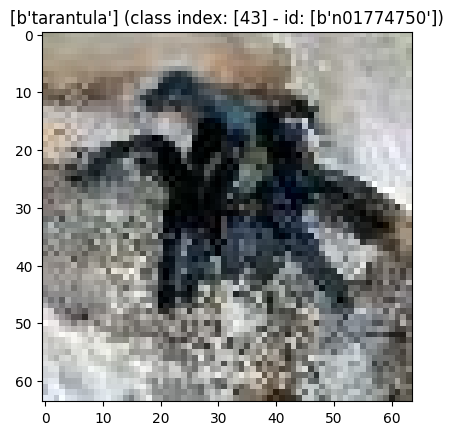

In [20]:
# Running infrence on our model
# We can run an infrence of our model by doing the following (we are doing batches of 1 here)
for example in ds_train.batch(1).take(1):
    img_info(example)
    
    # Make a prediction
    pred = model.predict(tf.cast(example["image"], tf.float32)/255.0)
    # print(f'Raw 200 Class Weighted Prediction:\n{pred}') # Uncomment to see the raw prediction
    
    # What is out best guess?
    best_guess = tf.math.argmax(pred, axis=1).numpy() # Our output is 200 weighted value, we want the most likely
    print(f'Best Guess [class index]: {class_names[best_guess[0]]} [{best_guess[0]}]')
    print(f'Best Guess Confidence (percent / 1.0): {pred[0][best_guess]}')

    # What are our top 15 guesses?
    top_15 = tf.math.top_k(pred, k=15)
    print(f'Top 15 Guesses (class index): {[f"{class_names[idx]} [{idx}]" for idx in top_15.indices[0]]}')
    print(f'Top 15 Guesses Confidence (percent / 1.0): {top_15.values}')

In [21]:
# TODO: Run infrence for our previous 3 sample images

# TODO: Your Code Here
for index, img_data in enumerate(sample_imgs):
    image = img_data["image"]

    #Run interface
    pred = model.predict(
        tf.expand_dims(tf.cast(image, tf.float32) / 255.0, axis = 0),
        verbose = 0
    )

    #Get best prediction
    best_guess = tf.math.argmax(pred, axis = 1).numpy()[0]
    confidence = pred[0][best_guess]

    #Actual class
    actual_class = img_class(img_data)

    print(f"Image {index}")
    print(f"Best Guess: {class_names[best_guess]}")
    print(f"Confidence: {confidence}")
    print(f"Actual Class: {actual_class}")
    print()
    


Image 0
Best Guess: ['cockroach', 'roach']
Confidence: 0.12765151262283325
Actual Class: b'snail' (class index: 33 - id: b'n01944390')

Image 1
Best Guess: ['cannon']
Confidence: 0.1076318547129631
Actual Class: b'cannon' (class index: 80 - id: b'n02950826')

Image 2
Best Guess: ['standard poodle']
Confidence: 0.05982786789536476
Actual Class: b'vestment' (class index: 104 - id: b'n04532106')



In [22]:
# TODO: Calculate the Top-1, Top-5, and Top-10 Accuracy of the validation dataset
total = acc_top1 = acc_top5 = acc_top10 = 0

# TODO: Your Code Here
for img_data in ds_val.take(10000):
    image = img_data["image"]
    actual_label = int(img_data["label"].numpy())

    #Run inference
    pred = model.predict(
        tf.expand_dims(tf.cast(image,tf.float32)/ 255.0,axis=0),#cast image to float32 and by divided to 255.0 normalize into 0~1 size.
        #unit8 size 0~255.
        verbose = 0 
    )

    #Get top 10 predictions
    top_10 = tf.math.top_k(pred, k=10).indices.numpy()[0]
    #getting top 10 model prediction class inndex

    #Count accuracy
    if actual_label == top_10[0]:
        #if actual_label matches top_10 prediction first class
        acc_top1 += 1

    if actual_label in top_10[:5]:
        #if actual_label matched top_10 prediction 1~5 class
        acc_top5 += 1

    if actual_label in top_10:
        #same logic
        acc_top10 += 1

    total += 1

print(f"Total Images: {total}")
print(f"Top-1 Accuracy: {acc_top1 / total * 100:.2f}%")
print(f"Top-5 Accuracy: {acc_top5 / total * 100:.2f}%")
print(f"Top-10 Accuracy: {acc_top10 / total * 100:.2f}%")

#The model has a relatively low Top-1 accuracy of 24.16%, while the Top-5 and Top-10 accuracies improve to 
#49.40% and 61.82%. We would not use this model for applications that require a highly accurate single prediction. 
#However, it could be still be useful in applications where multiple candidate predictions are acceptable.

2026-08-31 18:41:53.178256: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Total Images: 10000
Top-1 Accuracy: 24.30%
Top-5 Accuracy: 49.40%
Top-10 Accuracy: 61.74%


In [33]:
# TODO: Print all of the possible classes of the dataset

# TODO: Your Code Here
# Print all classes
print("All Classes:")
for index, name in enumerate(class_names):
    print(f"{index}: {name}")

# Count train and validation samples
train_count = ds_train.cardinality().numpy()
val_count = ds_val.cardinality().numpy()

print(f"\nNumber of Classes: {len(class_names)}")
print(f"Training Samples: {train_count}")
print(f"Validation Samples: {val_count}")
print(f"Total Samples: {train_count + val_count}")

#Reasons why many data points need?
#Because DNN train image characteristics by using data(ex.image) so need many training image for 
#more accurate prediction.

#Is our dataset small?
#Compare with current image datasets in company, it can says small. but it is not much small for our
#prediction.

All Classes:
0: ['Egyptian cat']
1: ['reel']
2: ['volleyball']
3: ['rocking chair', 'rocker']
4: ['lemon']
5: ['bullfrog', 'Rana catesbeiana']
6: ['basketball']
7: ['cliff', 'drop', 'drop-off']
8: ['espresso']
9: ['plunger', "plumber's helper"]
10: ['parking meter']
11: ['German shepherd', 'German shepherd dog', 'German police dog', 'alsatian']
12: ['dining table', 'board']
13: ['monarch', 'monarch butterfly', 'milkweed butterfly', 'Danaus plexippus']
14: ['brown bear', 'bruin', 'Ursus arctos']
15: ['school bus']
16: ['pizza', 'pizza pie']
17: ['guinea pig', 'Cavia cobaya']
18: ['umbrella']
19: ['organ', 'pipe organ']
20: ['oboe', 'hautboy', 'hautbois']
21: ['maypole']
22: ['goldfish', 'Carassius auratus']
23: ['potpie']
24: ['hourglass']
25: ['seashore', 'coast', 'seacoast', 'sea-coast']
26: ['computer keyboard', 'keypad']
27: ['Arabian camel', 'dromedary', 'Camelus dromedarius']
28: ['ice cream', 'icecream']
29: ['nail']
30: ['space heater']
31: ['cardigan']
32: ['baboon']
33: ['snai

## Model Exploration

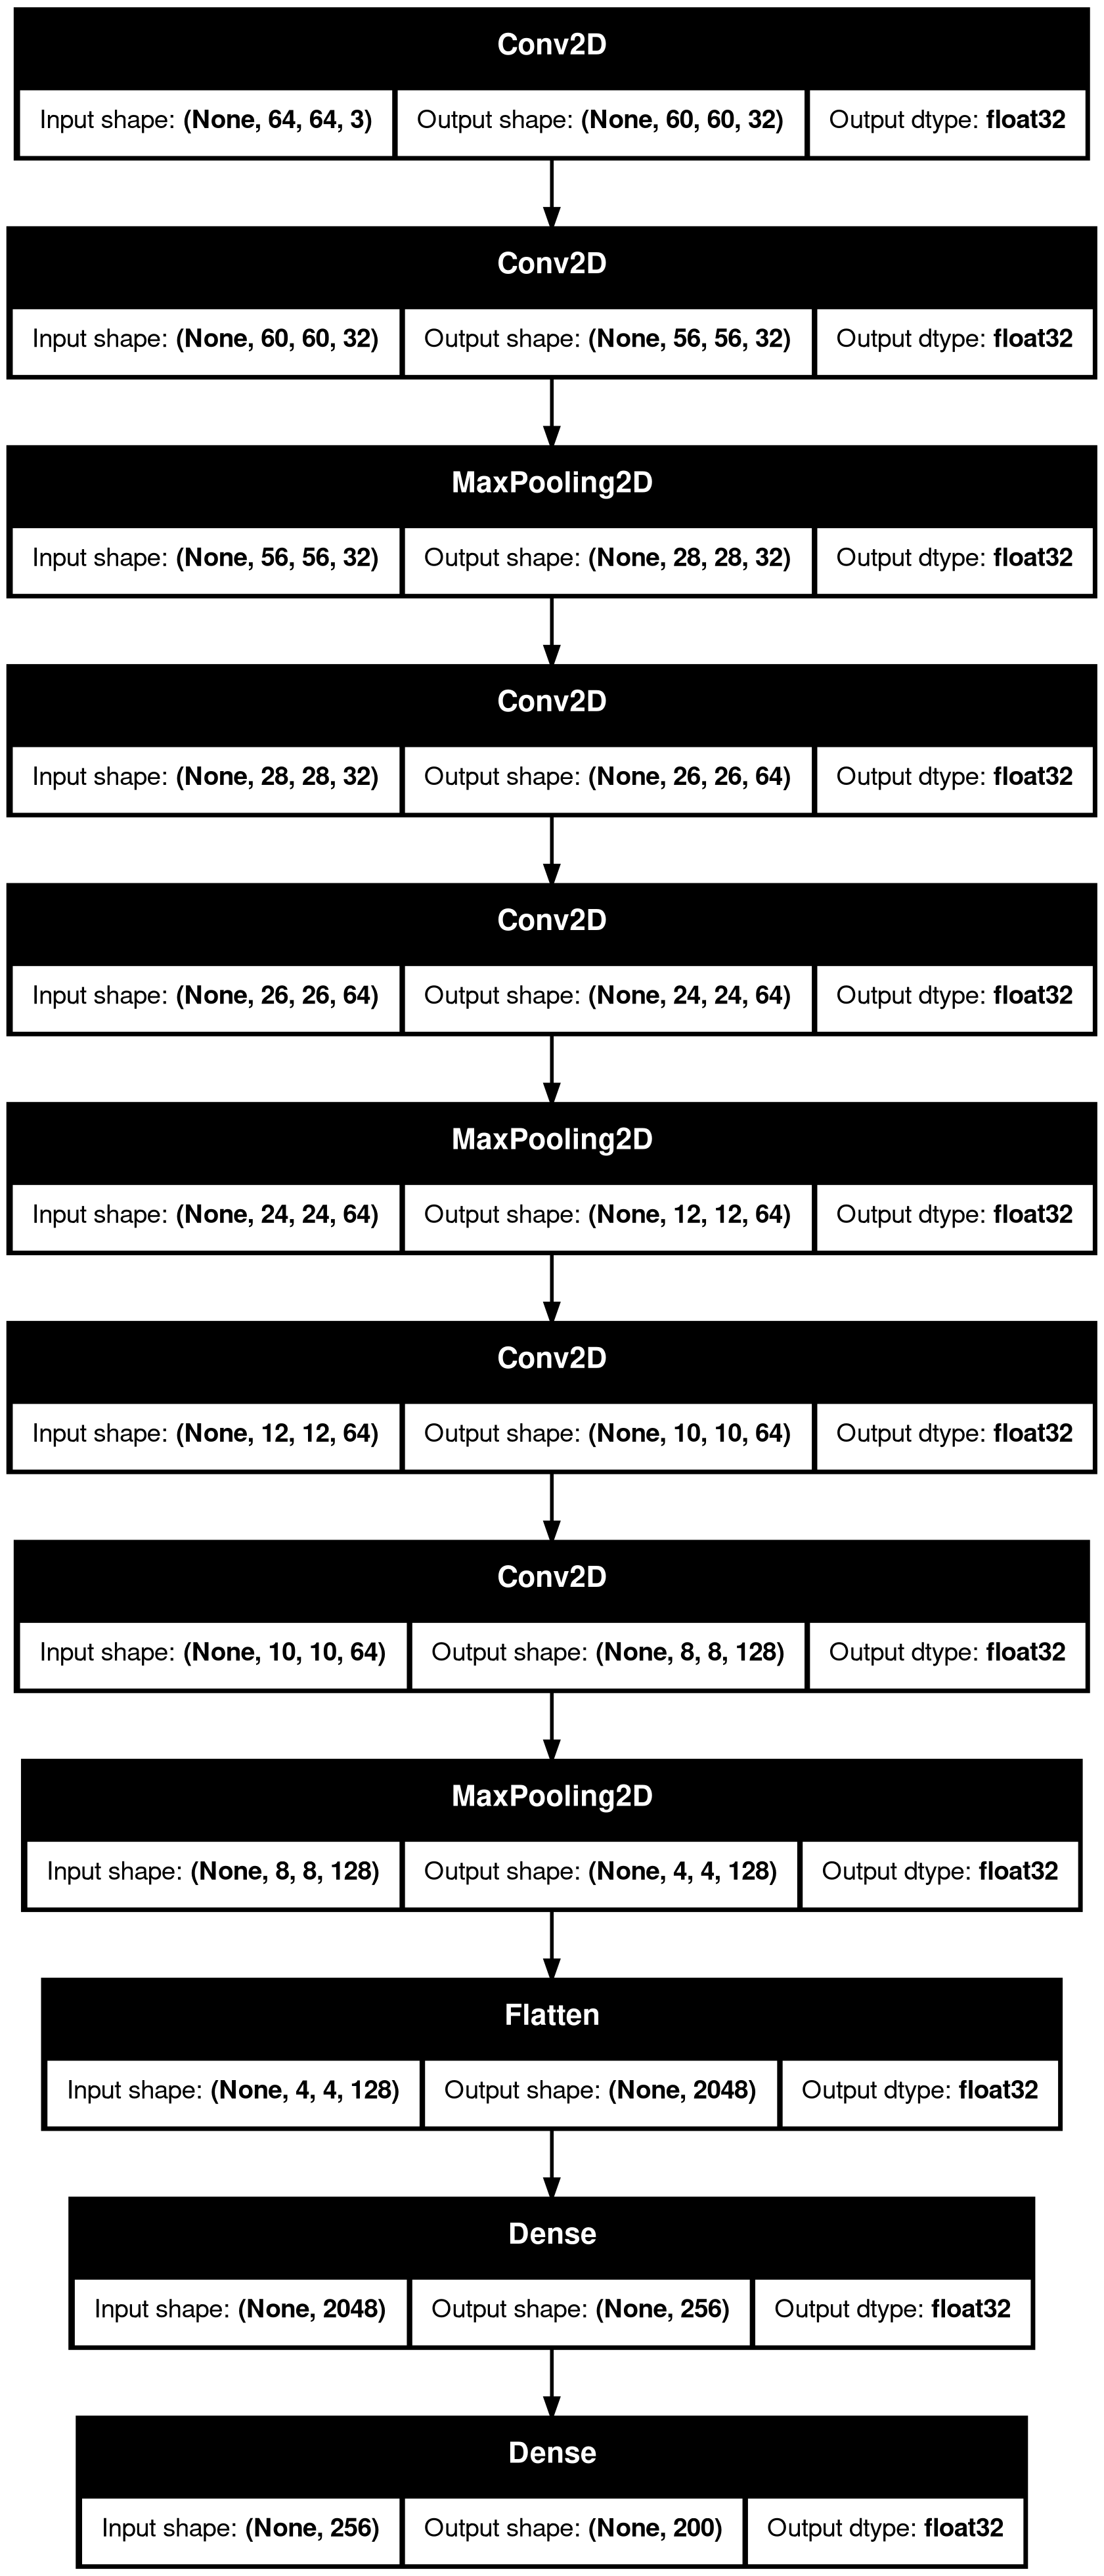

In [34]:
# TODO: Visualize the model in Netron (https://netron.app/) and include an image here.
tf.keras.utils.plot_model(model, "model.png", show_shapes=True, show_dtype=True, expand_nested=True) # Uncomment this to generate a simple visualization

=== Near Input Layer ===
Layer:conv2d
Kernel data type:float32
Kernel dimensions:(5, 5, 3, 32)
Kernel Memory:9600 bytes
Bias Dimensions:(32,)
Bias Memory:128 bytes
Total weight memory:9728 bytes


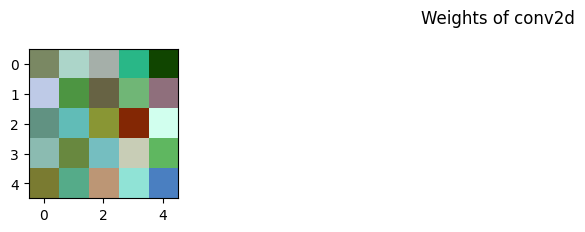

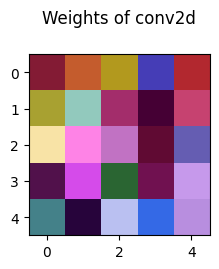

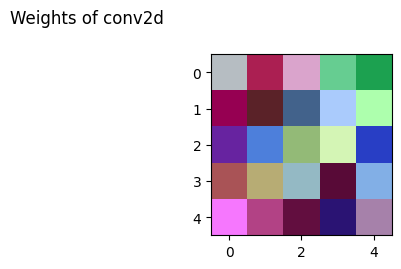

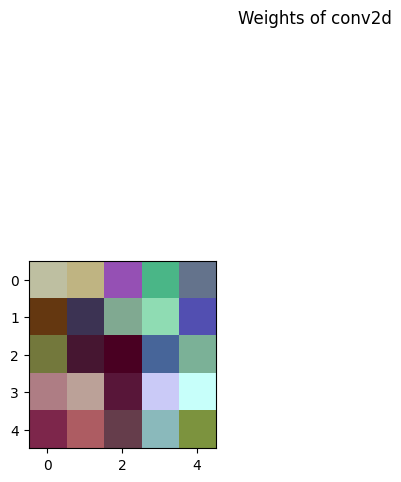

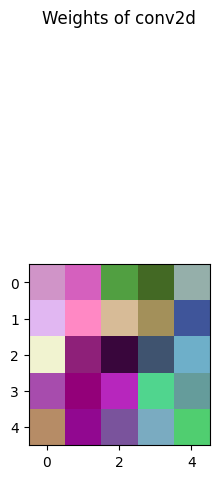

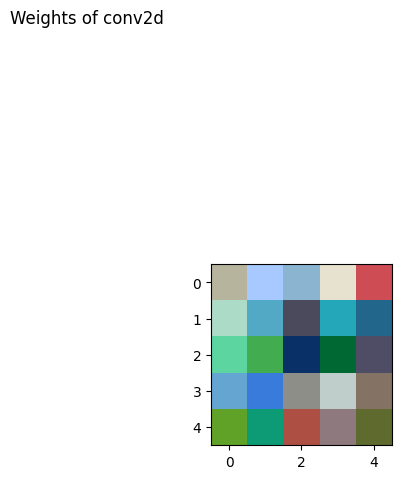


=== Near Output Layer ===
Layer:conv2d_5
Kernel data type:float32
Kernel dimensions:(3, 3, 64, 128)
Kernel Memory:294912 bytes
Bias Dimensions:(128,)
Bias Memory:512 bytes
Total weight memory:295424 bytes


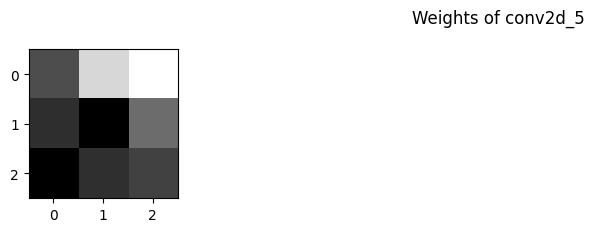

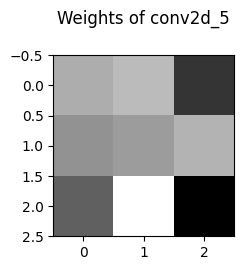

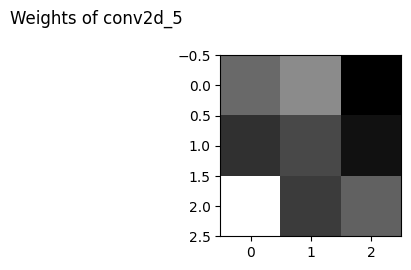

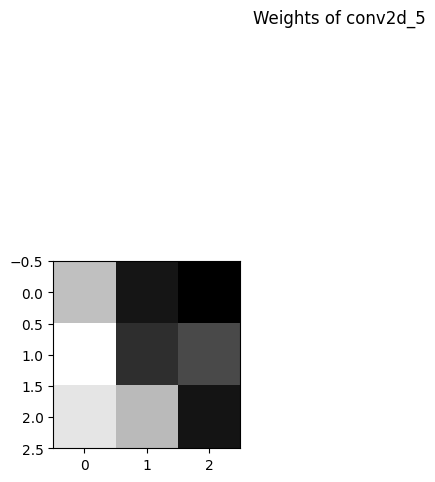

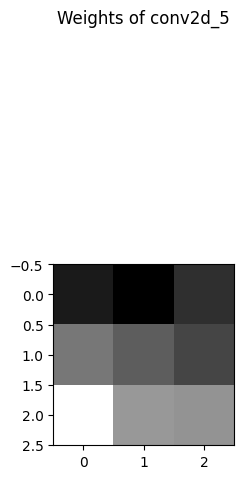

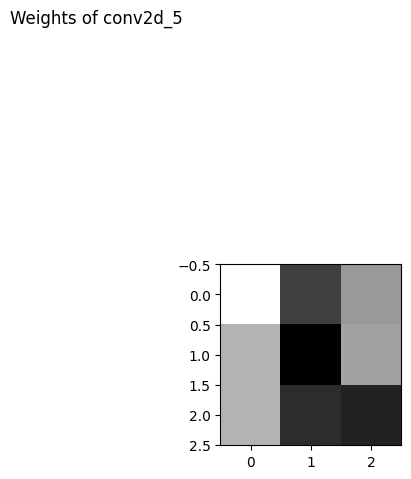

In [35]:
# We can view the layer weights. Here we consider them as images of feature filters applied to intermediate feature map images.
# TODO: Visualize the 2 convolutional layers filter sets (weights) (one at the beginning and one at the end)

# TODO: Your Code Here
#Find convolution layers
conv_layers = [
    layer for layer in model.layers
    if isinstance(layer,tf.keras.layers.Conv2D)
]

#Select one near input and one near output
early_layer = conv_layers[0] 
late_layer = conv_layers[-1]

def print_weight_info(layer):

    kernel, bias = layer.get_weights()

    print(f"Layer:{layer.name}")
    print(f"Kernel data type:{kernel.dtype}")
    print(f"Kernel dimensions:{kernel.shape}")
    print(f"Kernel Memory:{kernel.nbytes} bytes")
    print(f"Bias Dimensions:{bias.shape}")
    print(f"Bias Memory:{bias.nbytes} bytes")
    print(f"Total weight memory:{kernel.nbytes+bias.nbytes} bytes")

#Visualize representative filters
def visualize_weights(layer, num_filters=6):
    kernel = layer.get_weights()[0]

    plt.figure(figsize=(12,4))

    for i in range(min(num_filters,kernel.shape[-1])):
        plt.subplot(2,3,i+1)

        filt = kernel[:,:,:,i]

        #First layer has RGB input channels

        if filt.shape[-1] == 3:
            filt_min = filt.min()
            filt_max = filt.max()

            filt = (filt - filt_min) / (filt_max - filt_min + 1e-8)
            plt.imshow(filt)

        #Later layers have many input channels
        else:
            plt.imshow(np.mean(filt,axis=2),cmap="gray")

        plt.suptitle(f"Weights of {layer.name}")
        plt.tight_layout()
        plt.show()

#Near input layer
print("=== Near Input Layer ===")
print_weight_info(early_layer)
visualize_weights(early_layer)

#Near output layer
print("\n=== Near Output Layer ===")
print_weight_info(late_layer)
visualize_weights(late_layer)

2026-08-31 20:32:12.663448: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


--- First layer ---
Feature map shape: (1, 60, 60, 32)


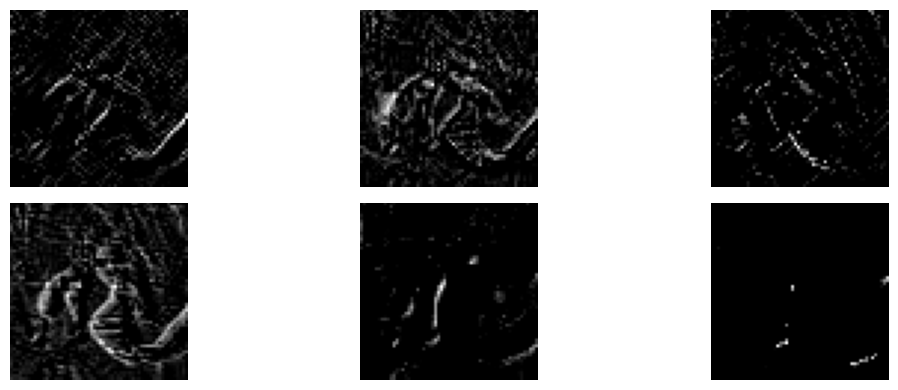

--- Last Layer --- 
Feature map shape: (1, 8, 8, 128)


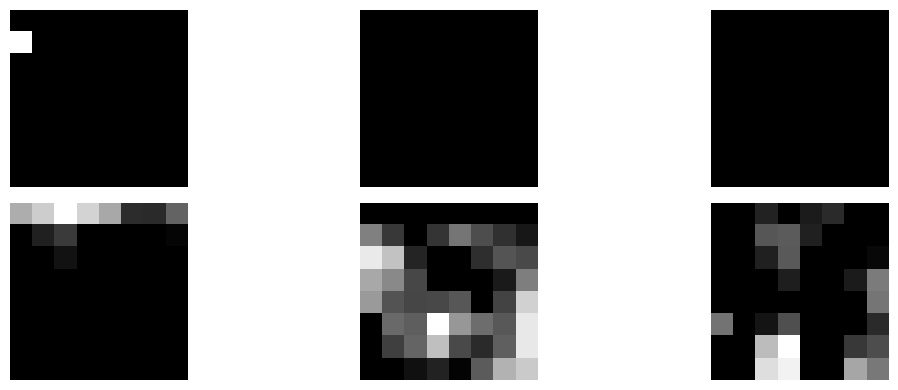

In [49]:
# We can view the layer outputs as well. Here we consider them as images of the spatial location of features.
# TODO: Visualize the 2 convolutional layers outputs (intermediate feature maps) (one at the beginning and one at the end)

# TODO: Your Code Here


# get the first and last layers
conv_layers = [
    layer for layer  in model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]


first_layer = conv_layers[0]
last_layer = conv_layers[-1]


active_model = tf.keras.Model(
    inputs = model.inputs,
    outputs = [first_layer.output, last_layer.output]
)

# grab a sample image
for img_data in ds_val.take(1):
    image = img_data["image"]
    label = img_data["label"].numpy()


input_tensor = tf.expand_dims(tf.cast(image, tf.float32) / 255.0, axis=0)

first_feature, last_feature = active_model.predict(input_tensor, verbose = 0)

def visualize_feature_maps(features, layer_name, num_maps=6):

    features = features[0]
    plt.figure(figsize=(12,4))
    for i in range(min(num_maps, features.shape[-1])):
        plt.subplot(2,3, i + 1)
        plt.imshow(features[: , :, i], cmap= "gray")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

print("--- First layer ---")
print(f'Feature map shape: {first_feature.shape}')
visualize_feature_maps(first_feature, first_layer.name)


print("--- Last Layer --- ")
print(f'Feature map shape: {last_feature.shape}')
visualize_feature_maps(last_feature, last_layer.name)

In [ ]:
# TODO: Export the filters/weights se we can use them later
# Make a directory for our image data
model_dir = os.path.abspath('model_data')
pathlib.Path(model_dir).mkdir(exist_ok=True)


# Export each image
conv_index = dense_index = 1 # layer index starts from one
for layer_idx, layer in enumerate(model.layers):
    if re.match(r'(conv|dense)', layer.name):
        weight_file_name = os.path.join(model_dir, f'{layer.name}_weights.bin')
        bias_file_name = os.path.join(model_dir, f'{layer.name}_bias.bin')
    else: continue

    assert layer.weights[0].name.endswith('kernel')
    assert layer.weights[1].name.endswith('bias')
        
    # TODO: Your Code Here

    kernel, bias = layer.get_weights()


    kernel.astype(np.float32).tofile(weight_file_name)
    bias.astype(np.float32).tofile(bias_file_name)


    print(f'Exported {layer.name}: kernel {kernel.shape}')
    print(f'{weight_file_name}, bias {bias.shape} {bias_file_name}')

0 conv2d_input InputLayer 0


IndexError: list index out of range

In [28]:
# TODO: Export the intermediate layer outputs for each of the input for all of the layers
img_dir = os.path.abspath('img_data')
pathlib.Path(img_dir).mkdir(exist_ok=True)

for img_idx, img in enumerate(sample_imgs):
    file_dir = os.path.join(img_dir, f'test_input_{img_idx}')
    pathlib.Path(file_dir).mkdir(exist_ok=True)
    
    # TODO: Your Code Here

## Tensorboard

In [29]:
# Setup for profiling
tf.profiler.experimental.ProfilerOptions(
    host_tracer_level=1, python_tracer_level=0, device_tracer_level=1
)

log_dir = os.path.abspath(os.path.join('log_data'))
log_dir_run = os.path.abspath(os.path.join(log_dir, datetime.datetime.now().strftime("%Y%m%d-%H%M%S")))
pathlib.Path(log_dir_run).mkdir(exist_ok=True, parents=True)

try:
    tf.profiler.experimental.stop()
except:
    test = 2
finally:
    test = 1

In [30]:
# TODO: Sample Profiling - Inference for a single image:

# Perform the inference profiling:
for example in ds_train.batch(1).take(1):
    # Starts Profile logging
    tf.profiler.experimental.start(log_dir_run)
    # Actual inference
    # TODO: Your Code Here

2026-08-31 18:42:29.781579: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2026-08-31 18:42:29.781846: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2026-08-31 18:42:29.782736: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-08-31 18:42:29.796654: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [31]:
# Load the TensorBoard notebook extension.
%load_ext tensorboard

# Launch TensorBoard and navigate to the Profile tab to view performance profile. 
# *** Please note just execute this command once in a session and 
# then logs for subsequent runs would be auto detected in tensorboard- url: http://localhost:6006/
print(log_dir)
%tensorboard --logdir={log_dir_run} --port=6006

# You can view the tensorboard in the browser url: http://localhost:6006/

# Useful command line to have if tensorboard is misbehaving: kill $(ps -e | grep 'tensorboard' | awk '{print $1}')

/home/zachdixo/cpre-487/lab01/cpre-487-587-lab1/log_data


In [32]:
# TODO: Sample Profiling - Online Inference:

# Vary this from 10, 100, 1000 to simulate multiple online inference
loop_index = [10, 100, 1000]

for idx in loop_index:
    # Starts Profile logging
    tf.profiler.experimental.start(log_dir_run)

    # Actual online inference
    # TODO: Your Code Here

AlreadyExistsError: Another profiler is running.

In [ ]:
# TODO: Sample Profiling - Batch Inference:

# We would only perform batch inference for a subset of validation set i.e. 1000 images 
# using different batch sizes of 20, 40, 100, 200 

# Decides the size of the batch. Try: 20, 40, 100, 200
batch_size = [20, 40, 100, 200]

for batch in batch_size:
    # Starts Profile logging
    tf.profiler.experimental.start(log_dir_run)

    # Actual Batch inference
    # TODO: Your Code Here

## Training

In [ ]:
# Setup for model training
from tensorflow.keras import Model, datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Dense, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, ZeroPadding2D,Convolution2D, Activation, Dropout 

train_dir = os.path.abspath(os.path.join('train_data', datetime.datetime.now().strftime("%Y%m%d-%H%M%S")))
pathlib.Path(train_dir).mkdir(exist_ok=True, parents=True)

# Using early stopping to monitor validation accuracy
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor="val_loss",
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=2,
        verbose=1,
    ),
    tf.keras.callbacks.TensorBoard(log_dir=train_dir, histogram_freq=1)
]

In [ ]:
# Basic CNN model
train_model = Sequential()

# conv1
train_model.add(Conv2D(32, (5, 5), input_shape=(64, 64, 3), activation='relu'))
train_model.add(Conv2D(32, (5,5),activation='relu'))
train_model.add(MaxPooling2D(pool_size=(2, 2)))
train_model.add(Conv2D(64, (3,3), activation='relu'))
train_model.add(Conv2D(64, (3,3), activation='relu'))
train_model.add(MaxPooling2D(pool_size=(2, 2)))
train_model.add(Conv2D(64, (3,3), activation='relu'))
train_model.add(Conv2D(128, (3,3), activation='relu'))
train_model.add(MaxPooling2D(pool_size=(2, 2)))
train_model.add(Flatten())

# fc1
train_model.add(Dense(256, activation='relu'))

# fc2
train_model.add(Dense(200, activation='softmax'))

train_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# TODO: Consider looking at different optimizers and learning rate settings
train_model.summary()

In [ ]:
# TODO: Attempt to train your own model with different batch sizes
# TODO: See how long this takes without a GPU on your VDI or 2050 Coover machines
# TODO: THEN log in to your GPU VM, set ENABLE_GPU = False in the very first cell, and re-run all above cells
# TODO: Make sure you have exported the LD_LIBRARY_PATH as the lab manual indicates

def normalize_img(image, label):
    return tf.cast(image, tf.float32) / 255., label

def to_categorical(image, label):
    label = tf.one_hot(tf.cast(label, tf.int32), 200)
    return tf.cast(image, tf.float32), tf.cast(label, tf.int64)

ds_re = tiny_imagenet_builder.as_dataset(as_supervised=True)
ds_retrain, ds_reval = ds_re["train"], ds_re["validation"]

ds_retrain = ds_retrain.cache().shuffle(1024)
ds_reval = ds_reval.cache().shuffle(1024)

ds_retrain = ds_retrain.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_reval = ds_reval.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)

ds_retrain = ds_retrain.map(to_categorical, num_parallel_calls=tf.data.AUTOTUNE)
ds_reval = ds_reval.map(to_categorical, num_parallel_calls=tf.data.AUTOTUNE)

epoch_size = 20


for batch_size in [32, 64, 128]:
    # Setup our batched datasets
    # TODO: Your Code Here

In [ ]:
# TODO: Train your model with 3 different numbers of epochs
batch_size = 32

# Setup your datasets
# TODO: Your Code Here

for epoch_size in [3, 10, 100]:
    # Run training
    # TODO: Your Code Here

    # Save the cnn model
    train_model.save(os.path.join(log_dir, f'CNN_TinyImageNet_train_batch{batch_size}.h5'))

    # TODO: Get the top-1 and top-5 of your newly trained model
    # TODO: Your Code Here

## Above and Beyond

In [ ]:
# Benchmark our dataset to make sure loading our data isn't a bottleneck ... and because we can
# (This can be skipped since it can take a bit and is't all that important)

# tfds.benchmark(ds_train.batch(32), batch_size=32, num_iter=2**20)

In [ ]:
# Explore new models to find a higher-accuracy model. Does the new model require more or less time?